In [73]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [2]:
data = pd.read_csv('data/shopify_sales_dataset_ml_eda.csv')
data.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [5]:
print(min(data['order_date']), max(data['order_date']))

2023-01-01 2025-06-18


In [12]:
sales_category = data.groupby('product_category')[['revenue', 'profit', 'discounted_price', 'shipping_cost']].sum()
sales_category['profit_margin'] = sales_category['profit']/sales_category['revenue']
sales_category.sort_values('revenue', ascending=False)

,revenue,profit,discounted_price,shipping_cost,profit_margin
product_category,,,,,
Electronics,8717301.49,8601068.01,2874477.23,116233.48,0.986666
Accessories,8609171.52,8492938.90,2844533.93,116232.62,0.986499
Home Decor,8545840.45,8428664.14,2837881.62,117176.31,0.986288
Beauty,8544881.95,8429076.60,2844109.52,115805.35,0.986447
Fashion,8445072.67,8327844.15,2799169.96,117228.52,0.986119
Sports,8434698.81,8319929.75,2827179.54,114769.06,0.986393
Footwear,8348968.69,8235108.55,2785860.92,113860.14,0.986362


In [22]:
orders = data.groupby('product_category')['order_id'].count()
sales_category['num_orders'] = sales_category.index.map(orders)
sales_category['avg_order_value'] = sales_category['revenue']/sales_category['num_orders']
sales_category['avg_profitability'] = sales_category['profit']/sales_category['num_orders']
sales_category

,revenue,profit,discounted_price,shipping_cost,profit_margin,num_orders,avg_order_value,avg_profitability
product_category,,,,,,,,
Accessories,8609171.52,8492938.90,2844533.93,116232.62,0.986499,8617,999.091507,985.602750
Beauty,8544881.95,8429076.60,2844109.52,115805.35,0.986447,8586,995.211035,981.723340
Electronics,8717301.49,8601068.01,2874477.23,116233.48,0.986666,8624,1010.818818,997.340910
Fashion,8445072.67,8327844.15,2799169.96,117228.52,0.986119,8594,982.670778,969.030038
Footwear,8348968.69,8235108.55,2785860.92,113860.14,0.986362,8457,987.225812,973.762392
Home Decor,8545840.45,8428664.14,2837881.62,117176.31,0.986288,8600,993.702378,980.077226
Sports,8434698.81,8319929.75,2827179.54,114769.06,0.986393,8522,989.755786,976.288401


In [23]:
# analysis on fashion
fashion = data[data['product_category']=='Fashion']

In [29]:
print(len(fashion['product_id'].unique()))
print(len(fashion['customer_id'].unique()))
print(len(fashion['order_id'].unique()))

4997
7761
8594


In [31]:
# Let's see if users are shopping cross categories
cross_cat_pur = data.groupby('customer_id')['product_category'].count().to_frame()
cross_cat_pur

,product_category
customer_id,
10000,1
10001,5
10002,2
10003,2
10004,1
...,...
49995,1
49996,3
49997,1


In [35]:
print(cross_cat_pur[cross_cat_pur['product_category']>1].size)
print(cross_cat_pur.size)

17832
31154


In [45]:
categories = data['product_category'].unique()

for cat in categories:
    cross_cat_pur[cat] = 0

purchases = data.groupby(['customer_id', 'product_category'])['order_id'].count().to_frame().reset_index()
purchases

,customer_id,product_category,order_id
0,10000,Accessories,1
1,10001,Fashion,1
2,10001,Footwear,1
3,10001,Home Decor,1
4,10001,Sports,2
...,...,...,...
54134,49996,Accessories,2
54135,49996,Fashion,1
54136,49997,Beauty,1
54137,49998,Sports,1


In [50]:
cross_pur = data.pivot_table(index='customer_id', columns='product_category', values='order_id', aggfunc='count', fill_value=0)
cross_pur

product_category,Accessories,Beauty,Electronics,Fashion,Footwear,Home Decor,Sports
customer_id,,,,,,,
10000,1,0,0,0,0,0,0
10001,0,0,0,1,1,1,2
10002,0,0,0,1,1,0,0
10003,0,0,0,1,0,1,0
10004,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
49995,0,0,0,0,1,0,0
49996,2,0,0,1,0,0,0
49997,0,1,0,0,0,0,0


In [53]:
print(cross_pur[(cross_pur['Accessories']>0) & (cross_pur['Beauty']>0)].size)

10787


In [69]:
cross_pur2 = pd.DataFrame(index=categories, columns=categories)
for cat in categories:
    for cat2 in categories:
        cross_pur2.at[cat, cat2] = cross_pur[(cross_pur[cat]>0) & (cross_pur[cat2]>0)].size/cross_pur[cross_pur[cat]>0].size

cross_pur2

,Accessories,Sports,Electronics,Footwear,Beauty,Fashion,Home Decor
Accessories,1.0,0.192842,0.193486,0.193486,0.198378,0.189882,0.1931
Sports,0.194849,1.0,0.193418,0.185744,0.190947,0.19563,0.187435
Electronics,0.192989,0.190935,1.0,0.192604,0.193503,0.195172,0.192604
Footwear,0.196317,0.18652,0.195925,1.0,0.192529,0.188218,0.191745
Beauty,0.19956,0.190106,0.195157,0.190883,1.0,0.193603,0.190754
Fashion,0.190053,0.193789,0.195851,0.185672,0.19263,1.0,0.189795
Home Decor,0.193399,0.185792,0.193399,0.189273,0.189917,0.189917,1.0


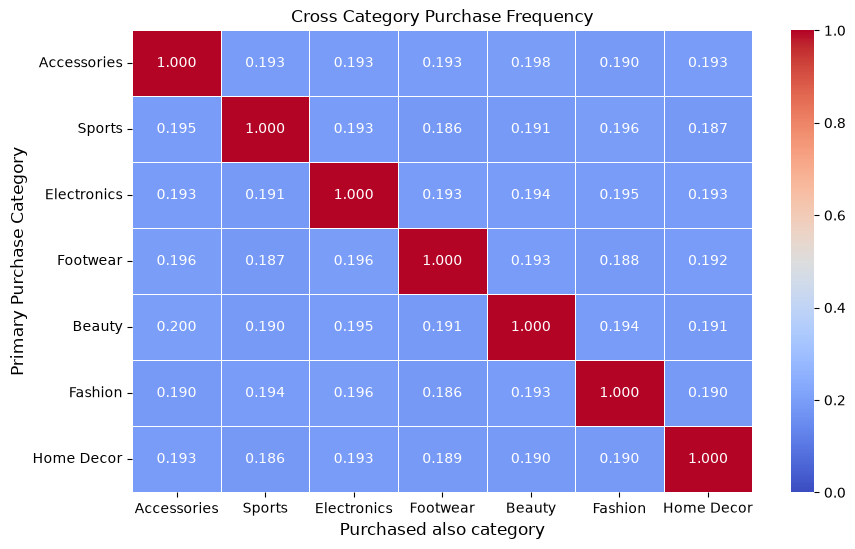

In [77]:
cross_pur2 = cross_pur2.astype(float)
plt.figure(figsize=(10,6))
sns.heatmap(cross_pur2, annot=True, cmap='coolwarm', fmt=".3f", vmin=0, vmax=1, linewidths=0.5, cbar={'label': 'Conditional Probability'})
plt.title('Cross Category Purchase Frequency')
plt.xlabel('Purchased also category', fontsize= 12)
plt.ylabel('Primary Purchase Category', fontsize=12)
plt.show()

In [ ]:
# Beauty and Accessories are the two most frequently cross purchased categories 
acces_beauty = 